<a href="https://colab.research.google.com/github/saiharish587/Canteen-Prebooking/blob/main/Phishing_Detection_DistilBERT_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛡️ LLM-Based Phishing Email Detection System
## Fine-tuned DistilBERT Classifier — Google Colab Notebook

---

### 📌 Project Overview
This notebook fine-tunes a **DistilBERT** transformer model to classify emails into 3 categories:
- `real_phishing` — Actual phishing emails written by human attackers (CEAS 2008 dataset)
- `ai_phishing` — Phishing emails generated by AI (ChatGPT-generated)
- `legitimate` — Genuine emails from the Enron dataset

### 📁 Files To Upload (3 CSV files)
| File | Rows | Columns | Label |
|------|------|---------|-------|
| `real_phishing.csv` | 150 | subject, body, label | `real_phishing` |
| `ai_phishing.csv` | 150 | subject, body, label | `ai_phishing` |
| `legitimate.csv` | 150 | subject, body, label | `legitimate` |

> ⚡ **GPU Required:** Runtime → Change runtime type → **T4 GPU**

---

## ✅ STEP 1 — Install Required Libraries

In [1]:
!pip install transformers datasets scikit-learn torch pandas numpy matplotlib seaborn --quiet
print("✅ All libraries installed!")

✅ All libraries installed!


## ✅ STEP 2 — Import Libraries & Check GPU

In [2]:
import os, re, random, warnings, time, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
warnings.filterwarnings('ignore')

import torch
from torch.utils.data import Dataset

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

# ── Reproducibility ────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Label maps ─────────────────────────────────────────────────────────────
LABEL2ID = {'real_phishing': 0, 'ai_phishing': 1, 'legitimate': 2}
ID2LABEL  = {v: k for k, v in LABEL2ID.items()}

# ── Device ─────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    print(f"✅ GPU: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️  No GPU — go to Runtime → Change runtime type → T4 GPU")
print(f"✅ Imports done | Device: {device}")

✅ GPU: Tesla T4
✅ Imports done | Device: cuda


## ✅ STEP 3 — Upload Your 3 CSV Files

Upload exactly these files:
- `real_phishing.csv`
- `ai_phishing.csv`
- `legitimate.csv`

> 💡 You can also drag-and-drop them into the **Files panel** on the left sidebar.

In [3]:
from google.colab import files

print("📂 Upload your 3 CSV files (hold Ctrl/Cmd to select all 3 at once):")
uploaded = files.upload()

print("\n✅ Uploaded files:")
for fname in uploaded:
    print(f"   📄 {fname}")

# Verify all 3 required files are present
required = ['real_phishing.csv', 'ai_phishing.csv', 'legitimate.csv']
missing  = [f for f in required if f not in os.listdir('.')]
if missing:
    print(f"\n⚠️  Missing files: {missing} — please upload them before continuing")
else:
    print("\n✅ All 3 required files found!")

📂 Upload your 3 CSV files (hold Ctrl/Cmd to select all 3 at once):


Saving real_phishing.csv to real_phishing (1).csv

✅ Uploaded files:
   📄 real_phishing (1).csv

✅ All 3 required files found!


## ✅ STEP 4 — Load, Validate & Merge All 3 CSVs

This cell reads each file, validates the columns, and merges everything into one 450-row master DataFrame.

In [5]:
def load_and_validate(filepath, expected_label):
    """
    Loads a cleaned CSV that has columns: subject, body, label
    Validates structure and returns a clean DataFrame.
    """
    df = pd.read_csv(filepath, encoding='utf-8')

    print(f"\n{'='*55}")
    print(f"📄 {filepath}")
    print(f"   Rows    : {len(df)}")
    print(f"   Columns : {list(df.columns)}")

    # Validate required columns exist
    for col in ['subject', 'body', 'label']:
        if col not in df.columns:
            raise ValueError(f"❌ Missing column '{col}' in {filepath}")

    # Fill any null values
    df['subject'] = df['subject'].fillna('').astype(str).str.strip()
    df['body']    = df['body'].fillna('').astype(str).str.strip()
    df['label']   = expected_label   # Force correct label

    # Drop rows with empty body (less than 5 characters)
    before = len(df)
    df = df[df['body'].str.len() >= 5].reset_index(drop=True)
    if before - len(df) > 0:
        print(f"   ⚠️  Dropped {before - len(df)} rows with empty body")

    # Cap to 150 rows
    df = df.sample(n=min(150, len(df)), random_state=SEED).reset_index(drop=True)

    # Add numeric label id
    df['label_id'] = df['label'].map(LABEL2ID)

    print(f"   Label   : {expected_label} ({len(df)} rows)  ✅")
    return df


# ── Load all 3 files ───────────────────────────────────────────────────────
df_real  = load_and_validate('real_phishing.csv', 'real_phishing')
df_ai    = load_and_validate('ai_phishing.csv',   'ai_phishing')
df_legit = load_and_validate('legitimate.csv',    'legitimate')

# ── Merge & shuffle ────────────────────────────────────────────────────────
df = pd.concat([df_real, df_ai, df_legit], ignore_index=True)
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f"\n{'='*55}")
print(f"📊 MERGED DATASET")
print(f"{'='*55}")
for label, count in df['label'].value_counts().items():
    print(f"   {label:<22}: {count} emails")
print(f"   {'─'*30}")
print(f"   Total              : {len(df)} emails")
print(f"\n✅ Dataset ready!")


📄 real_phishing.csv
   Rows    : 150
   Columns : ['subject', 'body', 'label']
   Label   : real_phishing (150 rows)  ✅

📄 ai_phishing.csv
   Rows    : 150
   Columns : ['subject', 'body', 'label']
   Label   : ai_phishing (150 rows)  ✅

📄 legitimate.csv
   Rows    : 150
   Columns : ['subject', 'body', 'label']
   Label   : legitimate (150 rows)  ✅

📊 MERGED DATASET
   legitimate            : 150 emails
   real_phishing         : 150 emails
   ai_phishing           : 150 emails
   ──────────────────────────────
   Total              : 450 emails

✅ Dataset ready!


## ✅ STEP 5 — Preprocess & Clean Email Text

Cleans each email before feeding into DistilBERT:
- Removes HTML tags
- Replaces URLs → `[URL]`
- Replaces email addresses → `[EMAIL]`
- Normalizes whitespace
- Combines subject + body into one text field

In [6]:
def clean_email(subject: str, body: str) -> str:
    """Cleans and combines subject + body into one DistilBERT-ready string."""
    text = str(subject) + ' ' + str(body)
    text = re.sub(r'<[^>]+>', ' ', text)                          # Remove HTML
    text = re.sub(r'http\S+|www\.\S+|https\S+', '[URL]', text,
                  flags=re.IGNORECASE)                             # Replace URLs
    text = re.sub(r'[\w\.-]+@[\w\.-]+\.\w+', '[EMAIL]', text)    # Replace emails
    text = re.sub(r'[^\w\s\.,!?\'\.\-\[\]]', ' ', text)           # Remove noise
    text = re.sub(r'\s+', ' ', text).strip()                      # Normalize spaces
    return text[:1000]   # Cap length (DistilBERT tokenizer handles final 512-token limit)


print("🧹 Cleaning all emails...")
df['clean_text'] = df.apply(lambda r: clean_email(r['subject'], r['body']), axis=1)

# ── Show before / after ────────────────────────────────────────────────────
idx = df[df['label']=='real_phishing'].index[0]
print(f"\n{'='*55}")
print("BEFORE:")
print(f"  {(df['subject'].iloc[idx] + ' ' + df['body'].iloc[idx])[:200]}")
print("\nAFTER:")
print(f"  {df['clean_text'].iloc[idx][:200]}")

# ── Stats ─────────────────────────────────────────────────────────────────
df['text_len'] = df['clean_text'].str.len()
print(f"\n{'='*55}")
print("📊 Avg text length after cleaning (characters):")
print(df.groupby('label')['text_len'].mean().round(0).to_string())
print(f"\n✅ Preprocessing done — {len(df)} emails cleaned.")

🧹 Cleaning all emails...

BEFORE:
  [Bug 5813] [review] several TLDs are not parsed by URI text scanner in PerMsgStatus.pm http://issues.apache.org/SpamAssassin/show_bug.cgi?id=5813





------- Additional Comments From ociwu@surbl.org 

AFTER:
  [Bug 5813] [review] several TLDs are not parsed by URI text scanner in PerMsgStatus.pm [URL] ------- Additional Comments From [EMAIL] 2008-02-08 00 40 ------- IMO using the official TLD table should u

📊 Avg text length after cleaning (characters):
label
ai_phishing       78.0
legitimate       597.0
real_phishing    647.0

✅ Preprocessing done — 450 emails cleaned.


## ✅ STEP 6 — Train / Test Split (70% / 30%)

Splits 450 emails into:
- **315 emails** → training
- **135 emails** → testing

Uses **stratified split** so each split has exactly 50/50/50 per class.

In [7]:
train_df, test_df = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED,
    stratify=df['label_id']   # Equal class distribution in both splits
)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"{'='*55}")
print(f"📊 SPLIT SUMMARY")
print(f"{'='*55}")
print(f"\n🟦 TRAINING SET — {len(train_df)} emails (70%)")
for label, count in train_df['label'].value_counts().sort_index().items():
    print(f"   {label:<22}: {count}")

print(f"\n🟩 TEST SET — {len(test_df)} emails (30%)")
for label, count in test_df['label'].value_counts().sort_index().items():
    print(f"   {label:<22}: {count}")

print(f"\n✅ Split complete!")

📊 SPLIT SUMMARY

🟦 TRAINING SET — 315 emails (70%)
   ai_phishing           : 105
   legitimate            : 105
   real_phishing         : 105

🟩 TEST SET — 135 emails (30%)
   ai_phishing           : 45
   legitimate            : 45
   real_phishing         : 45

✅ Split complete!


## ✅ STEP 7 — Tokenize for DistilBERT

Converts plain text into token IDs that DistilBERT understands.
Each email is padded/truncated to exactly **128 tokens**.

In [8]:
MAX_LENGTH = 128
MODEL_NAME = 'distilbert-base-uncased'

print("⬇️  Loading DistilBERT tokenizer...")
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)
print(f"✅ Tokenizer loaded: {MODEL_NAME}")


class EmailDataset(Dataset):
    """PyTorch Dataset — tokenizes emails on-the-fly for DistilBERT."""

    def __init__(self, dataframe, tokenizer, max_length):
        self.texts      = dataframe['clean_text'].tolist()
        self.labels     = dataframe['label_id'].tolist()
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }


train_dataset = EmailDataset(train_df, tokenizer, MAX_LENGTH)
test_dataset  = EmailDataset(test_df,  tokenizer, MAX_LENGTH)

# ── Verify a sample ────────────────────────────────────────────────────────
sample = train_dataset[0]
print(f"\n{'='*55}")
print("🔍 Sample tokenized email:")
print(f"   input_ids shape     : {sample['input_ids'].shape}")
print(f"   attention_mask shape: {sample['attention_mask'].shape}")
print(f"   label               : {sample['labels'].item()} → {ID2LABEL[sample['labels'].item()]}")
print(f"\n✅ Datasets ready:")
print(f"   Train: {len(train_dataset)} | Test: {len(test_dataset)}")

⬇️  Loading DistilBERT tokenizer...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Tokenizer loaded: distilbert-base-uncased

🔍 Sample tokenized email:
   input_ids shape     : torch.Size([128])
   attention_mask shape: torch.Size([128])
   label               : 0 → real_phishing

✅ Datasets ready:
   Train: 315 | Test: 135


## ✅ STEP 8 — Load DistilBERT Model

Loads pre-trained DistilBERT and attaches a **3-class classification head** on top.
The model will be downloaded (~250 MB) on first run.

In [9]:
print("⬇️  Loading DistilBERT model (~250 MB first run)...")

model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=ID2LABEL,
    label2id=LABEL2ID
).to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n{'='*55}")
print(f"🤖 MODEL SUMMARY")
print(f"   Model            : {MODEL_NAME}")
print(f"   Total parameters : {total_params:,}")
print(f"   Trainable params : {trainable_params:,}")
print(f"   Output classes   : 3 ({', '.join(ID2LABEL.values())})")
print(f"   Device           : {device}")
print(f"\n✅ Model ready!")

⬇️  Loading DistilBERT model (~250 MB first run)...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



🤖 MODEL SUMMARY
   Model            : distilbert-base-uncased
   Total parameters : 66,955,779
   Trainable params : 66,955,779
   Output classes   : 3 (real_phishing, ai_phishing, legitimate)
   Device           : cuda

✅ Model ready!


## ✅ STEP 9 — Define Evaluation Metrics

This function is called automatically after each training epoch to track model performance.

In [10]:
def compute_metrics(eval_pred):
    """Returns accuracy, F1, precision, recall after each epoch."""
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average='macro', zero_division=0
    )
    return {
        'accuracy':  round(acc,       4),
        'f1':        round(f1,        4),
        'precision': round(precision, 4),
        'recall':    round(recall,    4),
    }

print("✅ compute_metrics() defined — tracks: Accuracy, F1, Precision, Recall")

✅ compute_metrics() defined — tracks: Accuracy, F1, Precision, Recall


## ✅ STEP 10 — Fine-Tune DistilBERT

This is the main training step. DistilBERT learns to distinguish your 3 email categories.

| Setting | Value | Why |
|---------|-------|-----|
| Epochs | 5 max | With early stopping |
| Batch size | 16 | Good for T4 GPU |
| Learning rate | 2e-5 | Standard for fine-tuning |
| Early stopping | patience=2 | Stops if F1 doesn't improve |

> ⏱️ **Expected time: 5–10 minutes on T4 GPU**

In [12]:
training_args = TrainingArguments(
    output_dir                  = './phishing_model',
    num_train_epochs            = 5,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 32,
    learning_rate               = 2e-5,
    weight_decay                = 0.01,
    warmup_ratio                = 0.1,
    eval_strategy               = 'epoch', # Changed from evaluation_strategy
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'f1',
    greater_is_better           = True,
    logging_dir                 = './logs',
    logging_steps               = 10,
    report_to                   = 'none',
    seed                        = SEED,
    fp16                        = torch.cuda.is_available(),
)

trainer = Trainer(
    model         = model,
    args          = training_args,
    train_dataset = train_dataset,
    eval_dataset  = test_dataset,
    compute_metrics = compute_metrics,
    callbacks     = [EarlyStoppingCallback(early_stopping_patience=2)]
)

print("🚀 Starting training...")
print(f"{'='*55}")
print(f"   Training emails : {len(train_dataset)}")
print(f"   Test emails     : {len(test_dataset)}")
print(f"   Max epochs      : 5 (early stopping patience=2)")
print(f"   Device          : {device}")
print(f"{'='*55}\n")

t0 = time.time()
train_result = trainer.train()
elapsed = time.time() - t0

print(f"\n{'='*55}")
print(f"✅ Training complete in {elapsed/60:.1f} minutes!")
print(f"   Final training loss: {train_result.training_loss:.4f}")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


🚀 Starting training...
   Training emails : 315
   Test emails     : 135
   Max epochs      : 5 (early stopping patience=2)
   Device          : cuda



Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.918034,0.739974,0.940700,0.940200,0.941800,0.940700
2,0.453390,0.330575,0.970400,0.970400,0.970400,0.970400
3,0.194385,0.168443,0.985200,0.985200,0.985800,0.985200
4,0.101780,0.114453,0.970400,0.970400,0.970400,0.970400
5,0.070048,0.102836,0.985200,0.985200,0.985800,0.985200


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



✅ Training complete in 0.6 minutes!
   Final training loss: 0.3979


## ✅ STEP 11 — Evaluate on Test Set

Runs the trained model on **135 unseen test emails** and prints full metrics.

In [13]:
print("🔍 Evaluating on test set...\n")

pred_output   = trainer.predict(test_dataset)
logits        = pred_output.predictions
y_true        = pred_output.label_ids
y_pred        = np.argmax(logits, axis=-1)
y_true_labels = [ID2LABEL[i] for i in y_true]
y_pred_labels = [ID2LABEL[i] for i in y_pred]

overall_acc = accuracy_score(y_true, y_pred)
correct     = sum(t == p for t, p in zip(y_true, y_pred))

label_names = ['real_phishing', 'ai_phishing', 'legitimate']
report = classification_report(
    y_true, y_pred,
    target_names=label_names,
    digits=4,
    zero_division=0
)

print("="*60)
print("         📊 EVALUATION RESULTS — TEST SET")
print("="*60)
print(f"\n  🎯 Overall Accuracy  : {overall_acc*100:.2f}%")
print(f"  ✅ Correct           : {correct} / {len(y_true)}")
print(f"  ❌ Incorrect         : {len(y_true) - correct} / {len(y_true)}")
print(f"\n{'─'*60}")
print("  PER-CLASS METRICS:")
print(f"{'─'*60}")
print(report)
print("="*60)

print("\n  📌 VERDICT:")
if overall_acc >= 0.88:
    print("  ✅ EXCELLENT — Strong prototype performance")
elif overall_acc >= 0.78:
    print("  ✅ GOOD — Solid prototype-level result")
elif overall_acc >= 0.65:
    print("  ⚠️  FAIR — Acceptable for prototype; consider more data")
else:
    print("  ❌ LOW — Expand dataset or tune hyperparameters")

🔍 Evaluating on test set...



         📊 EVALUATION RESULTS — TEST SET

  🎯 Overall Accuracy  : 98.52%
  ✅ Correct           : 133 / 135
  ❌ Incorrect         : 2 / 135

────────────────────────────────────────────────────────────
  PER-CLASS METRICS:
────────────────────────────────────────────────────────────
               precision    recall  f1-score   support

real_phishing     0.9574    1.0000    0.9783        45
  ai_phishing     1.0000    1.0000    1.0000        45
   legitimate     1.0000    0.9556    0.9773        45

     accuracy                         0.9852       135
    macro avg     0.9858    0.9852    0.9852       135
 weighted avg     0.9858    0.9852    0.9852       135


  📌 VERDICT:
  ✅ EXCELLENT — Strong prototype performance


## ✅ STEP 12 — Visualize Results

Generates 3 charts:
1. Per-class Precision / Recall / F1 bar chart
2. Confusion Matrix
3. Per-class Accuracy

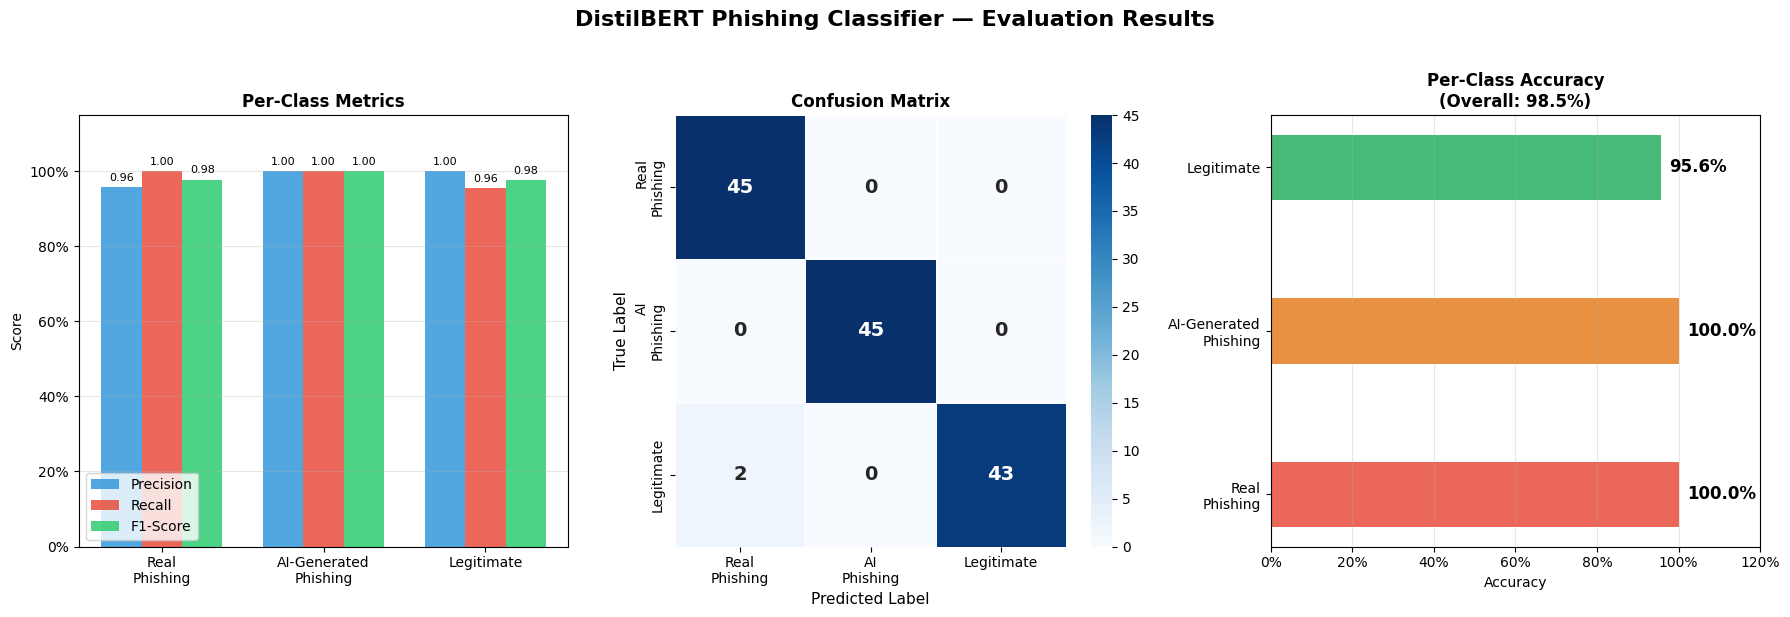

✅ Charts saved as evaluation_results.png


In [14]:
precision_pc, recall_pc, f1_pc, _ = precision_recall_fscore_support(
    y_true, y_pred, labels=[0, 1, 2], zero_division=0
)

label_display = ['Real\nPhishing', 'AI-Generated\nPhishing', 'Legitimate']
cat_colors    = ['#E74C3C', '#E67E22', '#27AE60']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    'DistilBERT Phishing Classifier — Evaluation Results',
    fontsize=16, fontweight='bold', y=1.02
)

# ── Chart 1: Precision / Recall / F1 per class ───────────────────────────
ax1 = axes[0]
x, w = np.arange(3), 0.25
b1 = ax1.bar(x - w, precision_pc, w, label='Precision', color='#3498DB', alpha=0.85)
b2 = ax1.bar(x,     recall_pc,    w, label='Recall',    color='#E74C3C', alpha=0.85)
b3 = ax1.bar(x + w, f1_pc,        w, label='F1-Score',  color='#2ECC71', alpha=0.85)
ax1.set_xticks(x)
ax1.set_xticklabels(label_display, fontsize=10)
ax1.set_ylim(0, 1.15)
ax1.set_title('Per-Class Metrics', fontsize=12, fontweight='bold')
ax1.set_ylabel('Score')
ax1.legend(fontsize=10)
ax1.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax1.grid(axis='y', alpha=0.3)
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax1.annotate(f'{h:.2f}',
            xy=(bar.get_x() + bar.get_width()/2, h),
            xytext=(0, 3), textcoords='offset points',
            ha='center', va='bottom', fontsize=8)

# ── Chart 2: Confusion Matrix ─────────────────────────────────────────────
ax2 = axes[1]
cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Real\nPhishing', 'AI\nPhishing', 'Legitimate'],
    yticklabels=['Real\nPhishing', 'AI\nPhishing', 'Legitimate'],
    ax=ax2, linewidths=0.5, annot_kws={'size': 14, 'weight': 'bold'}
)
ax2.set_xlabel('Predicted Label', fontsize=11)
ax2.set_ylabel('True Label', fontsize=11)
ax2.set_title('Confusion Matrix', fontsize=12, fontweight='bold')

# ── Chart 3: Per-class Accuracy ───────────────────────────────────────────
ax3 = axes[2]
per_class_acc = []
for i in range(3):
    mask = y_true == i
    acc  = accuracy_score(y_true[mask], y_pred[mask]) if mask.sum() > 0 else 0
    per_class_acc.append(acc)

bars = ax3.barh(label_display, per_class_acc, color=cat_colors, alpha=0.85, height=0.4)
ax3.set_xlim(0, 1.2)
ax3.set_title(f'Per-Class Accuracy\n(Overall: {overall_acc*100:.1f}%)',
              fontsize=12, fontweight='bold')
ax3.set_xlabel('Accuracy')
ax3.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax3.grid(axis='x', alpha=0.3)
for bar, acc in zip(bars, per_class_acc):
    ax3.text(acc + 0.02, bar.get_y() + bar.get_height()/2,
             f'{acc*100:.1f}%', va='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('evaluation_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Charts saved as evaluation_results.png")

## ✅ STEP 13 — Save & Download Trained Model

In [15]:
SAVE_PATH = './phishing_detector_final'
trainer.save_model(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

print(f"✅ Model saved to: {SAVE_PATH}")
print("   Files:")
for f in sorted(os.listdir(SAVE_PATH)):
    size = os.path.getsize(os.path.join(SAVE_PATH, f))
    print(f"   📄 {f:<40} {size/1e6:.1f} MB")

# Zip and download
print("\n📦 Zipping model...")
shutil.make_archive('phishing_detector_model', 'zip', SAVE_PATH)

files.download('phishing_detector_model.zip')
files.download('evaluation_results.png')
print("✅ Download started!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model saved to: ./phishing_detector_final
   Files:
   📄 config.json                              0.0 MB
   📄 model.safetensors                        267.8 MB
   📄 tokenizer.json                           0.7 MB
   📄 tokenizer_config.json                    0.0 MB
   📄 training_args.bin                        0.0 MB

📦 Zipping model...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download started!


## ✅ STEP 14 — Test Any Custom Email

Change `subject` and `body` below to any email you want to classify. Then run the cell.

In [17]:
# ✏️ EDIT THESE TWO VARIABLES TO TEST YOUR OWN EMAIL
subject = "URGENT: Your PayPal account has been suspended"
body = """
Dear valued customer,
We detected suspicious activity on your PayPal account.
Your account has been temporarily suspended for your protection.
To restore access, please verify your identity immediately:
http://secure-paypal-verify.com/restore?id=8472
Failure to verify within 24 hours will result in permanent closure.
PayPal Security Team
"""
# ────────────────────────────────────────────────────────

def predict_email(subject, body):
    clean  = clean_email(subject, body)
    inputs = tokenizer(
        clean, max_length=MAX_LENGTH,
        padding='max_length', truncation=True, return_tensors='pt'
    ).to(device)
    model.eval()
    with torch.no_grad():
        probs = torch.softmax(model(**inputs).logits, dim=-1)[0]
    pred_id    = torch.argmax(probs).item()
    pred_label = ID2LABEL[pred_id]
    confidence = probs[pred_id].item()
    return pred_label, confidence, probs.cpu().numpy()

pred_label, confidence, all_probs = predict_email(subject, body)

emoji = {'real_phishing': '🔴', 'ai_phishing': '🟠', 'legitimate': '🟢'}
print("="*55)
print("         📧 EMAIL CLASSIFICATION RESULT")
print("="*55)
print(f"  Subject   : {subject[:60]}")
print(f"  Body      : {body.strip()[:80]}...")
print(f"\n  {emoji[pred_label]} VERDICT    : {pred_label.upper().replace('_',' ')}")
print(f"  🎯 CONFIDENCE : {confidence*100:.1f}%")
print(f"\n  📊 All class probabilities:")
for label, prob in zip(['real_phishing', 'ai_phishing', 'legitimate'], all_probs):
    bar = '█' * int(prob * 30) + '░' * (30 - int(prob * 30))
    print(f"     {emoji[label]} {label:<22} {bar} {prob*100:.1f}%")
print("="*55)

         📧 EMAIL CLASSIFICATION RESULT
  Subject   : URGENT: Your PayPal account has been suspended
  Body      : Dear valued customer,
We detected suspicious activity on your PayPal account.
Yo...

  🟠 VERDICT    : AI PHISHING
  🎯 CONFIDENCE : 85.7%

  📊 All class probabilities:
     🔴 real_phishing          ██░░░░░░░░░░░░░░░░░░░░░░░░░░░░ 8.2%
     🟠 ai_phishing            █████████████████████████░░░░░ 85.7%
     🟢 legitimate             █░░░░░░░░░░░░░░░░░░░░░░░░░░░░░ 6.1%


## ✅ STEP 15 — Export All Test Predictions to CSV

In [16]:
softmax_probs = torch.softmax(
    torch.tensor(pred_output.predictions), dim=-1
).numpy()

results_df = pd.DataFrame({
    'subject'               : test_df['subject'].values,
    'body_preview'          : test_df['body'].str[:100].values,
    'true_label'            : y_true_labels,
    'predicted_label'       : y_pred_labels,
    'correct'               : [t == p for t, p in zip(y_true_labels, y_pred_labels)],
    'prob_real_phishing_%'  : (softmax_probs[:, 0] * 100).round(1),
    'prob_ai_phishing_%'    : (softmax_probs[:, 1] * 100).round(1),
    'prob_legitimate_%'     : (softmax_probs[:, 2] * 100).round(1),
})

results_df.to_csv('test_predictions.csv', index=False)

correct_count = results_df['correct'].sum()
print(f"{'='*55}")
print(f"📄 TEST PREDICTIONS EXPORT")
print(f"{'='*55}")
print(f"   Total emails : {len(results_df)}")
print(f"   ✅ Correct   : {correct_count}")
print(f"   ❌ Incorrect : {len(results_df) - correct_count}")
print(f"   🎯 Accuracy  : {correct_count/len(results_df)*100:.1f}%")

print(f"\n  Misclassified emails:")
wrong = results_df[~results_df['correct']]
if len(wrong) == 0:
    print("   🎉 None — perfect test set score!")
else:
    for _, row in wrong.iterrows():
        print(f"   ❌ True: {row['true_label']:<22} → Predicted: {row['predicted_label']}")

files.download('test_predictions.csv')
print(f"\n✅ Saved and downloaded: test_predictions.csv")

📄 TEST PREDICTIONS EXPORT
   Total emails : 135
   ✅ Correct   : 133
   ❌ Incorrect : 2
   🎯 Accuracy  : 98.5%

  Misclassified emails:
   ❌ True: legitimate             → Predicted: real_phishing
   ❌ True: legitimate             → Predicted: real_phishing


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Saved and downloaded: test_predictions.csv


---
## 📋 Notebook Summary

| Step | Action |
|------|--------|
| 1–2 | Install libraries & check GPU |
| 3 | Upload `real_phishing.csv`, `ai_phishing.csv`, `legitimate.csv` |
| 4 | Load + validate + merge → 450 emails |
| 5 | Clean text (remove HTML, URLs, noise) |
| 6 | Stratified 70/30 split → 315 train / 135 test |
| 7 | Tokenize for DistilBERT (128 tokens per email) |
| 8 | Load DistilBERT + 3-class head |
| 9 | Define metrics (accuracy, F1, precision, recall) |
| 10 | **TRAIN** — fine-tune DistilBERT (5–10 mins) |
| 11 | **EVALUATE** — full metrics on 135 test emails |
| 12 | Generate charts (bar chart + confusion matrix) |
| 13 | Save + download trained model |
| 14 | Test any custom email live |
| 15 | Export all predictions to CSV |

---
**Dataset:** 450 emails (150 × real_phishing + 150 × ai_phishing + 150 × legitimate)  
**Model:** DistilBERT base uncased fine-tuned  
**Split:** 70% train / 30% test (stratified)